# Homework 6: CNNs

CNN image classification using Fashion MNIST. This notebook includes a baseline model, several experiments, Optuna tuning, final test-set evaluation, and a short workflow reflection.


## Setup


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import fashion_mnist

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 545
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

2026-05-28 15:46:40.995195: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


KeyboardInterrupt: 

## Load Fashion MNIST


In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)
print("Pixel range before scaling:", X_train_full.min(), "to", X_train_full.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Pixel range before scaling: 0 to 255


## Visualize Images


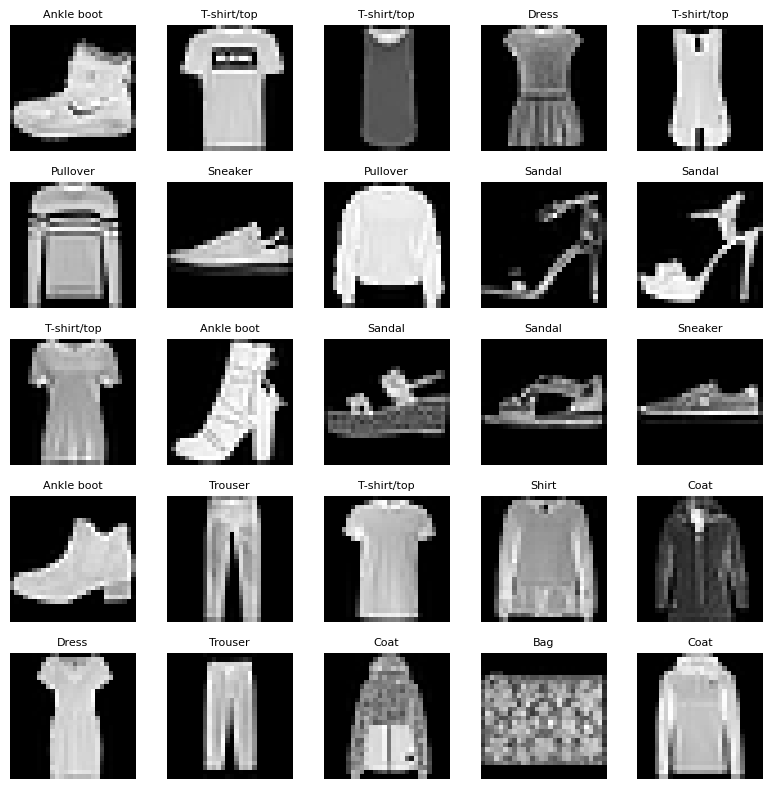

In [ ]:
plt.figure(figsize=(8, 8))
for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    ax.imshow(X_train_full[i], cmap="gray")
    ax.set_title(class_names[y_train_full[i]], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Prepare Data


In [ ]:
# Scale pixels and add grayscale channel dimension
X_train_full = (X_train_full.astype("float32") / 255.0)[..., np.newaxis]
X_test = (X_test.astype("float32") / 255.0)[..., np.newaxis]

# Hold out validation data from the original training set
val_size = 10000
X_val = X_train_full[-val_size:]
y_val = y_train_full[-val_size:]
X_train = X_train_full[:-val_size]
y_train = y_train_full[:-val_size]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (50000, 28, 28, 1) (50000,)
Validation: (10000, 28, 28, 1) (10000,)
Test: (10000, 28, 28, 1) (10000,)


## Helper Functions


In [ ]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["accuracy"], label="Train")
    axes[0].plot(history_df["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title}: Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="Train")
    axes[1].plot(history_df["val_loss"], label="Validation")
    axes[1].set_title(f"{title}: Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, history, name):
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    best_val_acc = max(history.history["val_accuracy"])
    best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)
    train_acc_at_best = history.history["accuracy"][best_epoch - 1]

    return {
        "model": name,
        "epochs_run": len(history.history["loss"]),
        "best_epoch": best_epoch,
        "train_acc_at_best": train_acc_at_best,
        "best_val_acc": best_val_acc,
        "final_val_acc": val_acc,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "val_train_gap_at_best": train_acc_at_best - best_val_acc
    }


def fit_model(model, name, epochs=15, batch_size=128):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    plot_history(history, name)
    return history, evaluate_model(model, history, name)


experiment_results = []
trained_models = {}

## Baseline CNN


In [ ]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 77ms/step - accuracy: 0.8184 - loss: 0.5061 - val_accuracy: 0.8760 - val_loss: 0.3468
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.8858 - loss: 0.3205 - val_accuracy: 0.8940 - val_loss: 0.2947
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9006 - loss: 0.2746 - val_accuracy: 0.9017 - val_loss: 0.2710
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.9122 - loss: 0.2427 - val_accuracy: 0.9052 - val_loss: 0.2586
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9211 - loss: 0.2175 - val_accuracy: 0.9088 - val_loss: 0.2509
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.9295 - loss: 0.1953 - val_accuracy: 0.9132 - val_loss: 0.2486
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9371 - loss: 0.1763 - val_accuracy: 0.9137 - val_loss: 0.2479
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.9443 - loss: 0.1585 - 

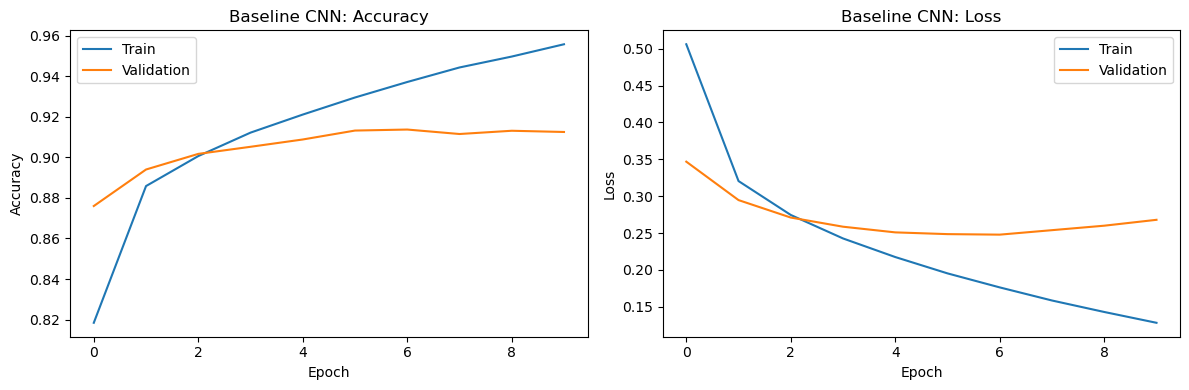

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344


In [ ]:
baseline_history, baseline_metrics = fit_model(baseline_model, "Baseline CNN")
experiment_results.append(baseline_metrics)
trained_models["Baseline CNN"] = baseline_model
pd.DataFrame(experiment_results)

## Experiment 1: Dropout

This tests whether dropout helps reduce overfitting compared with the baseline.


Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - accuracy: 0.7913 - loss: 0.5760 - val_accuracy: 0.8631 - val_loss: 0.3693
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.8685 - loss: 0.3672 - val_accuracy: 0.8797 - val_loss: 0.3205
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.8856 - loss: 0.3188 - val_accuracy: 0.8891 - val_loss: 0.2938
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.8954 - loss: 0.2866 - val_accuracy: 0.8996 - val_loss: 0.2683
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9051 - loss: 0.2641 - val_accuracy: 0.9072 - val_loss: 0.2513
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.9115 - loss: 0.2443 - val_accuracy: 0.9082 - val_loss: 0.2513
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9185 - loss: 0.2261 - val_accuracy: 0.9137 - val_loss: 0.2309
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9236 - loss: 0.2112 - 

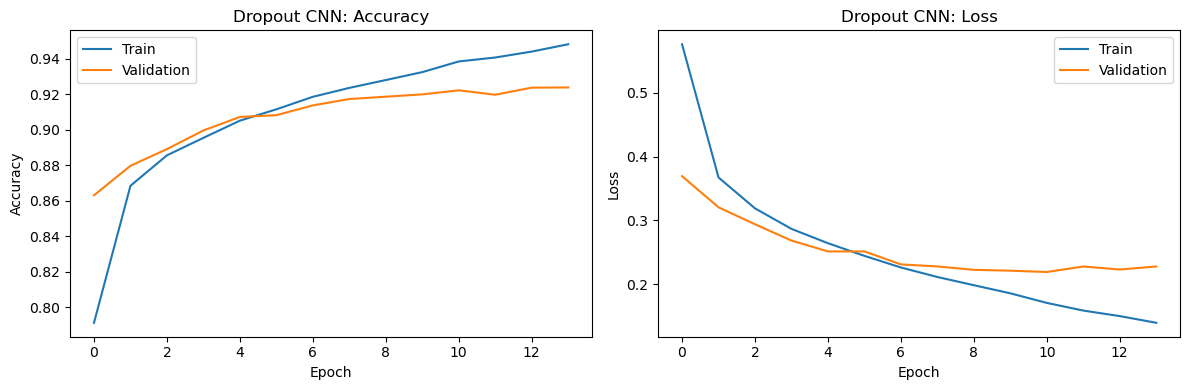

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344
1,Dropout CNN,14,14,0.94812,0.9238,0.9222,0.9158,0.241502,0.02432


In [ ]:
def build_dropout_model(dropout_rate=0.35):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

dropout_model = build_dropout_model()
dropout_history, dropout_metrics = fit_model(dropout_model, "Dropout CNN")
experiment_results.append(dropout_metrics)
trained_models["Dropout CNN"] = dropout_model
pd.DataFrame(experiment_results)

## Experiment 2: Batch Normalization

This tests whether batch normalization improves training stability and validation performance.


Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 121ms/step - accuracy: 0.8420 - loss: 0.4580 - val_accuracy: 0.7590 - val_loss: 0.6819
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 52s 132ms/step - accuracy: 0.8953 - loss: 0.2908 - val_accuracy: 0.8937 - val_loss: 0.2948
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.9126 - loss: 0.2442 - val_accuracy: 0.8999 - val_loss: 0.2787
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.9231 - loss: 0.2132 - val_accuracy: 0.8962 - val_loss: 0.2931
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - accuracy: 0.9313 - loss: 0.1887 - val_accuracy: 0.8974 - val_loss: 0.2847
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 54s 138ms/step - accuracy: 0.9396 - loss: 0.1676 - val_accuracy: 0.8963 - val_loss: 0.2894


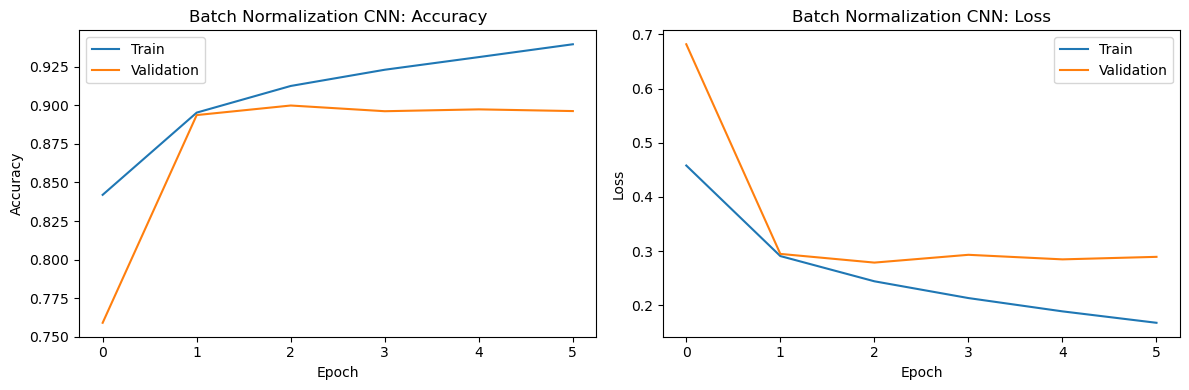

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344
1,Dropout CNN,14,14,0.94812,0.9238,0.9222,0.9158,0.241502,0.02432
2,Batch Normalization CNN,6,3,0.91258,0.8999,0.8999,0.8919,0.291692,0.01268


In [ ]:
def build_batchnorm_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

batchnorm_model = build_batchnorm_model()
batchnorm_history, batchnorm_metrics = fit_model(batchnorm_model, "Batch Normalization CNN")
experiment_results.append(batchnorm_metrics)
trained_models["Batch Normalization CNN"] = batchnorm_model
pd.DataFrame(experiment_results)

## Experiment 3: Data Augmentation

This tests whether small image transformations improve generalization.


Epoch 1/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.7354 - loss: 0.7176 - val_accuracy: 0.8225 - val_loss: 0.4650
Epoch 2/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.8174 - loss: 0.4931 - val_accuracy: 0.8585 - val_loss: 0.3751
Epoch 3/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.8387 - loss: 0.4369 - val_accuracy: 0.8627 - val_loss: 0.3612
Epoch 4/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8497 - loss: 0.4045 - val_accuracy: 0.8775 - val_loss: 0.3277
Epoch 5/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.8598 - loss: 0.3786 - val_accuracy: 0.8839 - val_loss: 0.3100
Epoch 6/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.8674 - loss: 0.3595 - val_accuracy: 0.8861 - val_loss: 0.3007
Epoch 7/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8735 - loss: 0.3436 - val_accuracy: 0.8897 - val_loss: 0.2823
Epoch 8/18
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.8780 - loss: 0.3302 - 

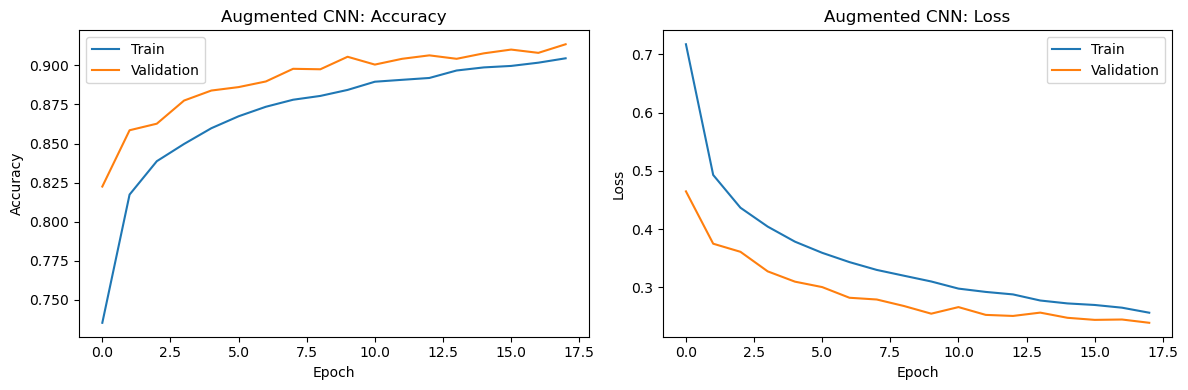

,model,epochs_run,best_epoch,train_acc_at_best,best_val_acc,final_val_acc,test_acc,test_loss,val_train_gap_at_best
0,Baseline CNN,10,7,0.93714,0.9137,0.9137,0.9033,0.263834,0.02344
1,Dropout CNN,14,14,0.94812,0.9238,0.9222,0.9158,0.241502,0.02432
2,Batch Normalization CNN,6,3,0.91258,0.8999,0.8999,0.8919,0.291692,0.01268
3,Augmented CNN,18,18,0.90452,0.9135,0.9135,0.9095,0.247889,-0.00898


In [ ]:
def build_augmented_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08, seed=SEED),
        layers.RandomZoom(height_factor=0.08, width_factor=0.08, seed=SEED),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

augmented_model = build_augmented_model()
augmented_history, augmented_metrics = fit_model(augmented_model, "Augmented CNN", epochs=18)
experiment_results.append(augmented_metrics)
trained_models["Augmented CNN"] = augmented_model
pd.DataFrame(experiment_results)

## Experiment 4: Wider CNN

This tests whether adding more filters improves performance enough to justify the extra complexity.


In [ ]:
def build_wider_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(48, 3, activation="relu", padding="same"),
        layers.Conv2D(48, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(96, 3, activation="relu", padding="same"),
        layers.Conv2D(96, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(160, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

wider_model = build_wider_model()
wider_history, wider_metrics = fit_model(wider_model, "Wider CNN", epochs=18)
experiment_results.append(wider_metrics)
trained_models["Wider CNN"] = wider_model
pd.DataFrame(experiment_results).sort_values("test_acc", ascending=False)

NameError: name 'keras' is not defined

## Compare Manual Experiments


In [ ]:
results_df = pd.DataFrame(experiment_results).sort_values("test_acc", ascending=False)
results_df.style.format({
    "train_acc_at_best": "{:.4f}",
    "best_val_acc": "{:.4f}",
    "final_val_acc": "{:.4f}",
    "test_acc": "{:.4f}",
    "test_loss": "{:.4f}",
    "val_train_gap_at_best": "{:.4f}"
})

## Optuna Tuning

Optuna searches across model width, dense units, dropout, learning rate, batch normalization, augmentation, L2 regularization, and batch size.


In [ ]:
try:
    import optuna
except ModuleNotFoundError:
    %pip install optuna -q
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 12
TUNING_EPOCHS = 10

In [ ]:
def build_tuned_model(trial):
    filters_1 = trial.suggest_categorical("filters_1", [24, 32, 48])
    filters_2 = trial.suggest_categorical("filters_2", [48, 64, 96])
    dense_units = trial.suggest_categorical("dense_units", [96, 128, 192])
    dropout_rate = trial.suggest_float("dropout_rate", 0.15, 0.50, step=0.05)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [False, True])
    use_augmentation = trial.suggest_categorical("use_augmentation", [False, True])
    l2_strength = trial.suggest_categorical("l2_strength", [0.0, 1e-5, 1e-4])

    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    if use_augmentation:
        model.add(layers.RandomTranslation(0.06, 0.06, seed=SEED))
        model.add(layers.RandomZoom(0.06, seed=SEED))

    for filters in [filters_1, filters_2]:
        model.add(layers.Conv2D(
            filters,
            kernel_size=3,
            padding="same",
            use_bias=not use_batchnorm,
            kernel_regularizer=regularizers.l2(l2_strength) if l2_strength else None
        ))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D(2))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation="relu"))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def objective(trial):
    model = build_tuned_model(trial)
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=TUNING_EPOCHS,
        batch_size=trial.suggest_categorical("batch_size", [64, 128]),
        callbacks=[early_stop],
        verbose=0
    )

    return max(history.history["val_accuracy"])

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS)

print("Best validation accuracy:", study.best_value)
print("Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

## Final Tuned Model


In [ ]:
class FixedTrial:
    def __init__(self, params):
        self.params = params
    def suggest_categorical(self, name, choices):
        return self.params[name]
    def suggest_float(self, name, low, high, step=None, log=False):
        return self.params[name]

best_trial = FixedTrial(study.best_params)
final_model = build_tuned_model(best_trial)
final_history, final_metrics = fit_model(
    final_model,
    "Final Optuna CNN",
    epochs=25,
    batch_size=study.best_params["batch_size"]
)

experiment_results.append(final_metrics)
trained_models["Final Optuna CNN"] = final_model
results_df = pd.DataFrame(experiment_results).sort_values("test_acc", ascending=False)
results_df

## Final Test Evaluation


In [ ]:
y_prob = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 9))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Final Model Confusion Matrix")
plt.tight_layout()
plt.show()

## Results Summary


In [ ]:
summary = results_df.sort_values("test_acc", ascending=False).reset_index(drop=True)
best = summary.iloc[0]
baseline = summary[summary["model"] == "Baseline CNN"].iloc[0]

print("Best model:", best["model"])
print(f"Best test accuracy: {best['test_acc']:.4f}")
print(f"Baseline test accuracy: {baseline['test_acc']:.4f}")
print(f"Improvement over baseline: {best['test_acc'] - baseline['test_acc']:.4f}")
print(f"Validation-training gap for best model: {best['val_train_gap_at_best']:.4f}")

if best["val_train_gap_at_best"] > 0.04:
    print("The best model shows noticeable overfitting because training accuracy is much higher than validation accuracy.")
elif best["val_train_gap_at_best"] > 0.02:
    print("The best model shows mild overfitting, but the validation gap is not extreme.")
else:
    print("The best model has a fairly small train-validation gap, suggesting reasonable generalization.")

print("
Full comparison:")
display(summary)

## Analysis

The baseline CNN is the reference model for comparing later changes. The manual experiments changed one main factor at a time, which made it easier to see whether dropout, batch normalization, augmentation, or a wider architecture helped validation and test performance.

Overfitting was evaluated by comparing training accuracy with validation accuracy and by checking whether validation loss increased while training loss continued to decrease. When a model had a larger train-validation gap, regularization and early stopping were more useful than simply adding epochs.

The final model was selected using Optuna based on validation accuracy, then evaluated on the held-out test set. The main tradeoff was between model capacity and generalization: larger models can learn more patterns, but they also train slower and can overfit more easily.


## Personal Workflow

In the future, I would start with a simple CNN baseline, then run controlled experiments that change one factor at a time. After identifying which changes seem useful, I would use Optuna to tune the most important hyperparameters.

I would prioritize preprocessing, validation strategy, learning rate, regularization, and model size. The biggest lesson is that the best model is not the one with the highest training accuracy; it is the one that performs well on validation and test data without showing too much overfitting.
